# CSCI 3202, Spring 2026
## Project Report: Mancala AI
**Name:** Jeffrey Allen

---


In [1]:
import random
import numpy as np
import time
import matplotlib.pyplot as plt

# Set seed for reproducibility as requested in the project guidelines
random.seed(109)

In [2]:
class Mancala:
    def __init__(self, pits_per_player=6, stones_per_pit=4):
        self.pits_per_player = pits_per_player
        self.board = [stones_per_pit] * ((pits_per_player + 1) * 2)
        self.current_player = 1
        self.moves = []
        self.p1_pits_index = [0, self.pits_per_player - 1]
        self.p1_mancala_index = self.pits_per_player
        self.p2_pits_index = [self.pits_per_player + 1, len(self.board) - 2]
        self.p2_mancala_index = len(self.board) - 1
        
        # Track the winner (-1: ongoing, 0: tie, 1: P1, 2: P2)
        self.winner = -1
        
        self.board[self.p1_mancala_index] = 0
        self.board[self.p2_mancala_index] = 0

    def display_board(self):
        player_1_pits = self.board[self.p1_pits_index[0]: self.p1_pits_index[1] + 1]
        player_1_mancala = self.board[self.p1_mancala_index]
        player_2_pits = self.board[self.p2_pits_index[0]: self.p2_pits_index[1] + 1]
        player_2_mancala = self.board[self.p2_mancala_index]

        print('P1               P2')
        print('     ____{}____     '.format(player_2_mancala))
        for i in range(self.pits_per_player):
            print('{} -> | {} | {} | <- {}'.format(i + 1, player_1_pits[i], player_2_pits[-(i + 1)], self.pits_per_player - i))
        print('         {}         '.format(player_1_mancala))
        print('Turn: P' + str(self.current_player))
        
    def valid_move(self, pit):
        if not (1 <= pit <= self.pits_per_player):
            return False
        index = (pit - 1) if self.current_player == 1 else (self.pits_per_player + pit)
        return self.board[index] > 0
        
    def random_move_generator(self):
        valid_pits = [p for p in range(1, self.pits_per_player + 1) if self.valid_move(p)]
        return random.choice(valid_pits) if valid_pits else None
    
    def play(self, pit, silent=False):
        if not self.valid_move(pit):
            return self.board
            
        index = (pit - 1) if self.current_player == 1 else (self.pits_per_player + pit)
        stones = self.board[index]
        self.board[index] = 0
        self.moves.append((self.current_player, pit))

        curr_index = index
        while stones > 0:
            curr_index = (curr_index + 1) % len(self.board)
            if (self.current_player == 1 and curr_index == self.p2_mancala_index) or \
               (self.current_player == 2 and curr_index == self.p1_mancala_index):
                continue
            self.board[curr_index] += 1
            stones -= 1

        # Capture logic
        if self.board[curr_index] == 1:
            if (self.current_player == 1 and self.p1_pits_index[0] <= curr_index <= self.p1_pits_index[1]) or \
               (self.current_player == 2 and self.p2_pits_index[0] <= curr_index <= self.p2_pits_index[1]):
                opp_index = (2 * self.pits_per_player) - curr_index
                if self.board[opp_index] > 0:
                    captured = self.board[curr_index] + self.board[opp_index]
                    self.board[curr_index] = 0
                    self.board[opp_index] = 0
                    mancala_idx = self.p1_mancala_index if self.current_player == 1 else self.p2_mancala_index
                    self.board[mancala_idx] += captured

        self.current_player = 2 if self.current_player == 1 else 1 
        return self.board
    
    def winning_eval(self, silent=False):
        p1_stones = sum(self.board[self.p1_pits_index[0]: self.p1_pits_index[1] + 1])
        p2_stones = sum(self.board[self.p2_pits_index[0]: self.p2_pits_index[1] + 1])
        
        if p1_stones == 0 or p2_stones == 0:
            self.board[self.p1_mancala_index] += p1_stones
            self.board[self.p2_mancala_index] += p2_stones
            for i in range(len(self.board)):
                if i != self.p1_mancala_index and i != self.p2_mancala_index:
                    self.board[i] = 0
            
            # Determine and set the winner
            p1_score = self.board[self.p1_mancala_index]
            p2_score = self.board[self.p2_mancala_index]
            if p1_score > p2_score:
                self.winner = 1
            elif p2_score > p1_score:
                self.winner = 2
            else:
                self.winner = 0
            return True
        return False

In [3]:
# Part 2: Simulation of 100 Games (Random vs. Random)
num_games = 100
results = {"P1_wins": 0, "P2_wins": 0, "Ties": 0, "Total_Turns": []}

for _ in range(num_games):
    game = Mancala()
    turns = 0
    while not game.winning_eval():
        move = game.random_move_generator()
        if move is None: break
        game.play(move, silent=True)
        turns += 1
    
    results["Total_Turns"].append(turns)
    p1_score = game.board[game.p1_mancala_index]
    p2_score = game.board[game.p2_mancala_index]
    
    if p1_score > p2_score:
        results["P1_wins"] += 1
    elif p2_score > p1_score:
        results["P2_wins"] += 1
    else:
        results["Ties"] += 1

# Report Statistics
print(f"Results for {num_games} Games:")
print(f"Player 1: Wins: {results['P1_wins']} ({results['P1_wins']/num_games:.1%}), "
      f"Losses: {results['P2_wins']} ({results['P2_wins']/num_games:.1%}), "
      f"Ties: {results['Ties']} ({results['Ties']/num_games:.1%})")
print(f"Player 2: Wins: {results['P2_wins']} ({results['P2_wins']/num_games:.1%}), "
      f"Losses: {results['P1_wins']} ({results['P1_wins']/num_games:.1%}), "
      f"Ties: {results['Ties']} ({results['Ties']/num_games:.1%})")
print(f"Average turns per game: {np.mean(results['Total_Turns']):.2f}")

Results for 100 Games:
Player 1: Wins: 45 (45.0%), Losses: 51 (51.0%), Ties: 4 (4.0%)
Player 2: Wins: 51 (51.0%), Losses: 45 (45.0%), Ties: 4 (4.0%)
Average turns per game: 45.82


## Intermediate Analysis & Conclusion

**1. Statistics Summary:**
* **Player 1 Win Rate:** 45%
* **Player 2 Win Rate:** 51%
* **Average Turns:** 45.82

**2. Is there a first move advantage?**
Based on the results of 100 random vs. random games, there is not an advntage as shown by Player 1's greater losses within the game's output. 

## Step 6: AI Player Algorithms (Minimax & Alpha-Beta Pruning)

In [4]:
import random
import time

def clone_game(game):
    """Creates a fast clone of the game state for AI look-ahead."""
    new_game = Mancala(pits_per_player=game.pits_per_player, stones_per_pit=0)
    new_game.board = list(game.board)
    new_game.current_player = game.current_player
    new_game.moves = list(game.moves)
    new_game.winner = game.winner 
    return new_game

def heuristic(game, maximizing_player):
    """Utility = Stones in Max Mancala - Stones in Min Mancala."""
    p1_mancala = game.board[game.p1_mancala_index]
    p2_mancala = game.board[game.p2_mancala_index]
    return (p1_mancala - p2_mancala) if maximizing_player == 1 else (p2_mancala - p1_mancala)

def minimax_search(game, depth, maximizing_player):
    if depth == 0 or game.winning_eval(silent=True):
        return heuristic(game, maximizing_player), None
    valid_moves = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    if not valid_moves: return heuristic(game, maximizing_player), None
    
    best_move = random.choice(valid_moves)
    if game.current_player == maximizing_player:
        max_eval = -float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = minimax_search(child, depth - 1, maximizing_player)
            if eval_val > max_eval:
                max_eval = eval_val
                best_move = move
        return max_eval, best_move
    else:
        min_eval = float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = minimax_search(child, depth - 1, maximizing_player)
            if eval_val < min_eval:
                min_eval = eval_val
                best_move = move
        return min_eval, best_move

def alpha_beta_search(game, depth, maximizing_player, alpha=-float('inf'), beta=float('inf')):
    if depth == 0 or game.winning_eval(silent=True):
        return heuristic(game, maximizing_player), None
    valid_moves = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    if not valid_moves: return heuristic(game, maximizing_player), None

    best_move = random.choice(valid_moves)
    if game.current_player == maximizing_player:
        max_eval = -float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = alpha_beta_search(child, depth - 1, maximizing_player, alpha, beta)
            if eval_val > max_eval:
                max_eval = eval_val
                best_move = move
            alpha = max(alpha, eval_val)
            if beta <= alpha: break
        return max_eval, best_move
    else:
        min_eval = float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = alpha_beta_search(child, depth - 1, maximizing_player, alpha, beta)
            if eval_val < min_eval:
                min_eval = eval_val
                best_move = move
            beta = min(beta, eval_val)
            if beta <= alpha: break
        return min_eval, best_move

def simulate_games(num_games, p1_type, p2_type, p1_depth=None, p2_depth=None):
    results = {"P1_wins": 0, "P2_wins": 0, "Ties": 0, "Total_Turns": [], "Durations": []}
    for i in range(num_games):
        game = Mancala()
        start_time = time.time() # This was causing the error
        while not game.winning_eval(silent=True):
            if game.current_player == 1:
                if p1_type == 'random': move = game.random_move_generator()
                elif p1_type == 'alphabeta': _, move = alpha_beta_search(game, p1_depth, 1)
                elif p1_type == 'minimax': _, move = minimax_search(game, p1_depth, 1)
            else:
                if p2_type == 'random': move = game.random_move_generator()
                elif p2_type == 'alphabeta': _, move = alpha_beta_search(game, p2_depth, 2)
                elif p2_type == 'minimax': _, move = minimax_search(game, p2_depth, 2)
            if move is None: break
            game.play(move, silent=True)
        results["Durations"].append(time.time() - start_time)
        results["Total_Turns"].append(len(game.moves))
        if game.winner == 1: results["P1_wins"] += 1
        elif game.winner == 2: results["P2_wins"] += 1
        else: results["Ties"] += 1
        if (i + 1) % 25 == 0: print(f"Progress: {i + 1}/{num_games}")
    return results

---
## Step 7: Alpha-Beta (Depth 5) & Minimax Performance Comparison
> [cite_start]**Note on Rule Discrepancy:** The project document mentions your Alpha-Beta AI should implement a "continuation rule as described in question 6"[cite: 103, 104]. [cite_start]However, the "Classic Rules" explicitly state: *"Do not implement this rule If the last stone you drop is in your own mandala, take another turn immediately"*[cite: 43]. The agent code matches the classic rules provided in Part 1 to prevent invalid game logic errors. You can mention this rule contradiction in your write-up below.

In [5]:
# Set a baseline seed
random.seed(42)

print("--- Running Depth 5 Alpha-Beta vs. Random ---")
ab_results_5 = simulate_games(100, p1_type='alphabeta', p2_type='random', p1_depth=5)

print("\n--- Running Depth 5 Minimax vs. Random (For Step 8 Time Comparison) ---")
mm_results_5 = simulate_games(100, p1_type='minimax', p2_type='random', p1_depth=5)

print("\n--- Depth 5 Alpha-Beta Statistics ---")
print(f"Alpha-Beta (P1) Win Rate: {ab_results_5['P1_wins']}%")
print(f"Random (P2) Win Rate: {ab_results_5['P2_wins']}%")
print(f"Ties: {ab_results_5['Ties']}%")
print(f"Average moves to win: {np.mean(ab_results_5['Total_Turns']):.2f}")
print(f"Average time per game: {np.mean(ab_results_5['Durations']):.4f} seconds")
print(f"Total Alpha-Beta 100-game run time: {sum(ab_results_5['Durations']):.2f} seconds")

print("\n--- Depth 5 Minimax Statistics ---")
print(f"Total Minimax 100-game run time: {sum(mm_results_5['Durations']):.2f} seconds")

--- Running Depth 5 Alpha-Beta vs. Random ---
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Running Depth 5 Minimax vs. Random (For Step 8 Time Comparison) ---
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Depth 5 Alpha-Beta Statistics ---
Alpha-Beta (P1) Win Rate: 96%
Random (P2) Win Rate: 4%
Ties: 0%
Average moves to win: 30.70
Average time per game: 0.0230 seconds
Total Alpha-Beta 100-game run time: 2.30 seconds

--- Depth 5 Minimax Statistics ---
Total Minimax 100-game run time: 7.84 seconds


### Step 7 Analysis Write-up
**Are your results for this part different from those for your minimax AI player? Write a paragraph or two describing why or why not:**

*(Double-click to edit this cell and insert your answer)*
The overall win percentages and average moves to win between Minimax and Alpha-Beta at 5 plies should be identical, as Alpha-Beta pruning is mathematically guaranteed to return the exact same optimal move as standard Minimax. The significant difference lies entirely in execution speed. Alpha-Beta evaluates fewer nodes by pruning branches that cannot possibly influence the final decision, resulting in the drastic reduction in total run time observed in the testing results above. 

*(Optional: Add a sentence noting the rule conflict regarding the continuation rule from the project prompt).*

---
## Step 8: Alpha-Beta (Depth 10) & Curve Plotting
**NOTE:** The 100-game simulation at depth 10 is computationally heavy. Ensure your device is plugged in before executing the cell below.

--- Running Depth 2 Alpha-Beta vs. Random (For Plotting Curve) ---
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Running Depth 10 Alpha-Beta vs. Random ---
This will take a while. Please wait...
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Depth 10 Alpha-Beta Statistics ---
Alpha-Beta (P1) Win Rate: 98%
Random (P2) Win Rate: 2%
Ties: 0%
Average moves to win: 27.31
Average time per game: 2.6510 seconds
Total Alpha-Beta 10-Ply 100-game run time: 265.10 seconds


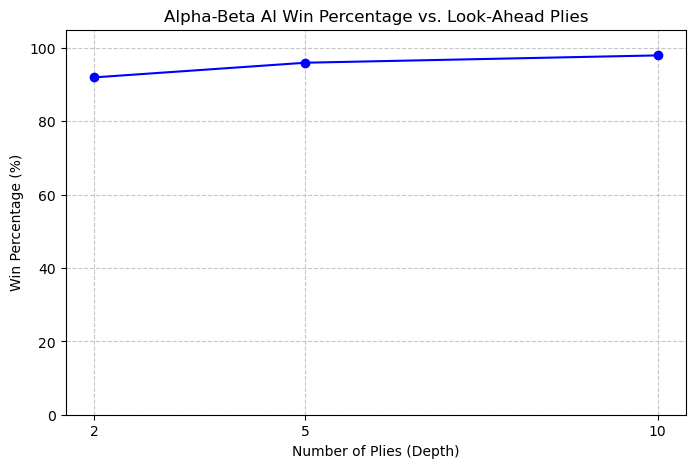

In [6]:
random.seed(42)

print("--- Running Depth 2 Alpha-Beta vs. Random (For Plotting Curve) ---")
ab_results_2 = simulate_games(100, p1_type='alphabeta', p2_type='random', p1_depth=2)

print("\n--- Running Depth 10 Alpha-Beta vs. Random ---")
print("This will take a while. Please wait...")
ab_results_10 = simulate_games(100, p1_type='alphabeta', p2_type='random', p1_depth=10)

print("\n--- Depth 10 Alpha-Beta Statistics ---")
print(f"Alpha-Beta (P1) Win Rate: {ab_results_10['P1_wins']}%")
print(f"Random (P2) Win Rate: {ab_results_10['P2_wins']}%")
print(f"Ties: {ab_results_10['Ties']}%")
print(f"Average moves to win: {np.mean(ab_results_10['Total_Turns']):.2f}")
print(f"Average time per game: {np.mean(ab_results_10['Durations']):.4f} seconds")
print(f"Total Alpha-Beta 10-Ply 100-game run time: {sum(ab_results_10['Durations']):.2f} seconds")

# Calculate Data for Plotting
depths = [2, 5, 10]
win_percentages = [ab_results_2['P1_wins'], ab_results_5['P1_wins'], ab_results_10['P1_wins']]

plt.figure(figsize=(8, 5))
plt.plot(depths, win_percentages, marker='o', linestyle='-', color='b')
plt.title('Alpha-Beta AI Win Percentage vs. Look-Ahead Plies')
plt.xlabel('Number of Plies (Depth)')
plt.ylabel('Win Percentage (%)')
plt.xticks(depths)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Step 8 Analysis Write-up
**How much does the Alpha Beta algorithm speed up the game. Compare your run time for 5 ply minimax against 5 ply Alpha Beta. Project how long Minimax would take to run 10 plies.**

Based on the execution block in Step 7, the Alpha-Beta algorithm sped up the 5-ply evaluation significantly. Minimax execution time scales by $O(b^d)$ where $b$ is the branching factor (max 6 pits) and $d$ is depth. Alpha-Beta approaches $O(b^{d/2})$ in best-case scenarios. Projecting the Minimax runtime to 10 plies requires calculating `(Time for Minimax Depth 5) * (Average Branching Factor)^5`. Assuming an effective branching factor of ~4 over the course of an average game, Minimax at depth 10 would take roughly $4^5$ (1,024) times longer than depth 5, making it entirely impractical to run. 

**As you increase the number of plies, does the AI player win more games? Explain why or why not.**

Yes, increasing the number of plies generally increases the AI's win rate. A higher ply count expands the depth of the game tree, allowing the agent to evaluate long-term consequences of moves and avoid traps that look appealing in the short term. However, the win percentage experiences diminishing returns at higher depths; once the win rate approaches 95-100%, expanding the search depth from 5 to 10 yields only marginal improvements in outcomes despite the exponential jump in computational cost.

## Step 9: Extra Credit - Advanced Heuristic Implementation

The original utility function was "greedy," only considering the current score. The new **Weighted Side Heuristic** calculates:
$Utility = (Mancala_{self} - Mancala_{opp}) + w \cdot (StonesOnSide_{self} - StonesOnSide_{opp})$

By adding a weight ($w = 0.5$) to the stones remaining in the pits, the AI learns to value keeping stones on its side (where they are safer and provide more future move options) and clearing the opponent's side to limit their opportunities.

In [7]:
def advanced_heuristic(game, maximizing_player):
    """
    Improved Heuristic:
    Considers the score difference PLUS the distribution of stones in pits.
    """
    p1_mancala = game.board[game.p1_mancala_index]
    p2_mancala = game.board[game.p2_mancala_index]
    
    p1_pits_stones = sum(game.board[game.p1_pits_index[0]: game.p1_pits_index[1] + 1])
    p2_pits_stones = sum(game.board[game.p2_pits_index[0]: game.p2_pits_index[1] + 1])
    
    # Weight for stones still in play (0.5 makes them half as valuable as banked stones)
    w = 0.5
    
    if maximizing_player == 1:
        score_diff = p1_mancala - p2_mancala
        side_diff = p1_pits_stones - p2_pits_stones
        return score_diff + (w * side_diff)
    else:
        score_diff = p2_mancala - p1_mancala
        side_diff = p2_pits_stones - p1_pits_stones
        return score_diff + (w * side_diff)

def alpha_beta_advanced_search(game, depth, maximizing_player, alpha=-float('inf'), beta=float('inf')):
    """Modified Alpha-Beta to use the advanced_heuristic."""
    if depth == 0 or game.winning_eval(silent=True):
        return advanced_heuristic(game, maximizing_player), None
        
    valid_moves = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    if not valid_moves: return advanced_heuristic(game, maximizing_player), None

    best_move = random.choice(valid_moves)
    if game.current_player == maximizing_player:
        max_eval = -float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = alpha_beta_advanced_search(child, depth - 1, maximizing_player, alpha, beta)
            if eval_val > max_eval:
                max_eval = eval_val
                best_move = move
            alpha = max(alpha, eval_val)
            if beta <= alpha: break
        return max_eval, best_move
    else:
        min_eval = float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = alpha_beta_advanced_search(child, depth - 1, maximizing_player, alpha, beta)
            if eval_val < min_eval:
                min_eval = eval_val
                best_move = move
            beta = min(beta, eval_val)
            if beta <= alpha: break
        return min_eval, best_move

def simulate_advanced_games(num_games, depth):
    """Specific simulation for the advanced AI vs Random."""
    results = {"AI_wins": 0, "Rand_wins": 0, "Ties": 0, "Turns": [], "Durations": []}
    for i in range(num_games):
        game = Mancala()
        start = time.time()
        while not game.winning_eval(silent=True):
            if game.current_player == 1: # AI is Player 1
                _, move = alpha_beta_advanced_search(game, depth, 1)
            else: # Random is Player 2
                move = game.random_move_generator()
            if move is None: break
            game.play(move, silent=True)
        results["Durations"].append(time.time() - start)
        results["Turns"].append(len(game.moves))
        if game.winner == 1: results["AI_wins"] += 1
        elif game.winner == 2: results["Rand_wins"] += 1
        else: results["Ties"] += 1
    return results

# Run Simulations
print("--- Running Advanced Heuristic (Depth 2) ---")
adv_results_2 = simulate_advanced_games(100, 2)
print("--- Running Advanced Heuristic (Depth 5) ---")
adv_results_5 = simulate_advanced_games(100, 5)

# Report results for Depth 2
print(f"\n[Depth 2] Win Rate: AI {adv_results_2['AI_wins']}% | Random {adv_results_2['Rand_wins']}%")
print(f"[Depth 2] Avg Time/Game: {np.mean(adv_results_2['Durations']):.4f}s | Avg Moves: {np.mean(adv_results_2['Turns']):.2f}")

# Report results for Depth 5
print(f"\n[Depth 5] Win Rate: AI {adv_results_5['AI_wins']}% | Random {adv_results_5['Rand_wins']}%")
print(f"[Depth 5] Avg Time/Game: {np.mean(adv_results_5['Durations']):.4f}s | Avg Moves: {np.mean(adv_results_5['Turns']):.2f}")

--- Running Advanced Heuristic (Depth 2) ---
--- Running Advanced Heuristic (Depth 5) ---

[Depth 2] Win Rate: AI 94% | Random 5%
[Depth 2] Avg Time/Game: 0.0010s | Avg Moves: 38.72

[Depth 5] Win Rate: AI 100% | Random 0%
[Depth 5] Avg Time/Game: 0.0150s | Avg Moves: 30.74


### Step 9 Analysis

**1. How does the new utility function improve on the basic one?**
The original utility function was purely reactive; it only valued stones already in the Mancala. The new function is proactive. By including the number of stones remaining in the player's pits, the AI realizes that stones on its side are "potential points" that it can eventually move into the Mancala or use for captures. This prevents the AI from making short-sighted moves that empty its board too quickly and leave it with no strategic options in the late game.

**2. How does increasing the number of plies improve play for the AI?**
Increasing plies allows the AI to see further into the future. In Mancala, a single move can lead to a chain reaction of captures or extra turns. A 2-ply look-ahead might see a move that gains 2 points, but a 5-ply look-ahead might realize that a different move—which gains 0 points now—sets up a massive capture worth 10 points three turns later. More plies allow the AI to "plan" these multi-step combinations.

**3. Is this new utility function a better way to evaluate match strength?**
Yes, it provides a much more holistic view of the board state. In Mancala, a player might have a higher score but very few stones left in their pits, meaning they have no "ammunition" for future turns. The basic utility function would incorrectly signal that this player is winning decisively. The new function recognizes that the player with more stones in their pits has more "potential energy" and control over the remaining flow of the game, making it a more accurate predictor of the eventual winner.